# Monobank Finance X-Ray: Exploratory Data Analysis (EDA)

The goal of this notebook is to analyze raw transaction data retrieved from the Monobank API, understand spending patterns, and identify potential features for future Machine Learning models (e.g., anomaly detection, category clustering).

## 1. Environment Setup & Data Loading
Importing required modules and initializing our custom ETL pipeline components.

In [46]:
import os
import sys
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.database import engine

load_dotenv('../.env')

True

## 2. Fetching Recent Transactions
Retrieving transaction history using our database.

In [47]:
query = "SELECT * FROM transactions ORDER BY time"
df = pd.read_sql(query, engine)

print(f"There are {len(df)} transactions.")

df.head()

There are 3839 transactions.


,id,time,description,mcc,amount,balance,cashbackAmount,category
0,B8mYHuANLS1Z4fKL,2021-10-25 12:05:37,Від: Андрій Щербінін,4829,70.00,70.00,0.00,Money Transfers
1,ALt_lDa2i4QaIbHd,2021-10-25 14:21:37,АТБ №792,5499,-18.40,51.60,0.36,Markets / Specialty Foods
2,BCY5yG1vrciwLWww,2021-10-25 17:07:58,Сільпо,5411,-14.49,37.11,0.28,Supermarkets / Groceries
3,XvcsoKuQVfRnKvAI,2021-10-25 17:28:49,Від: Андрій Щербінін,4829,20.00,57.11,0.00,Money Transfers
4,utrNd308W9Jvdy7w,2021-10-25 17:31:28,АТБ,5411,-34.50,22.61,0.69,Supermarkets / Groceries


## 3. Basic Data Inspection
Checking data types, missing values, and basic statistical summaries of our financial data.

In [48]:
print("Dataset info:")
df.info()

print("\nStatistical summary:")
display(df.describe())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 3839 entries, 0 to 3838
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              3839 non-null   str           
 1   time            3839 non-null   datetime64[us]
 2   description     3839 non-null   str           
 3   mcc             3839 non-null   int64         
 4   amount          3839 non-null   float64       
 5   balance         3839 non-null   float64       
 6   cashbackAmount  3839 non-null   float64       
 7   category        3839 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), str(3)
memory usage: 240.1 KB

Statistical summary:


,time,mcc,amount,balance,cashbackAmount
count,3839,3839.000000,3839.000000,3839.000000,3839.000000
mean,2024-11-04 20:22:27.150820,5167.808283,0.069245,1453.720250,0.941026
min,2021-10-25 12:05:37,742.000000,-21445.240000,0.000000,-67.210000
25%,2024-04-20 18:58:41.500000,4829.000000,-89.350000,325.220000,0.000000
50%,2025-01-04 09:28:11,4829.000000,-17.970000,1105.930000,0.000000
75%,2025-10-08 06:25:28,5499.000000,-0.500000,1986.535000,0.220000
max,2026-06-03 12:58:26,9402.000000,14999.990000,28271.990000,455.000000
std,NaN,795.527159,918.201431,1646.411319,12.711334


## 4. Data Visualization
Visualizing balance trends and monthly expense distributions to identify behavioral patterns and potential outliers.

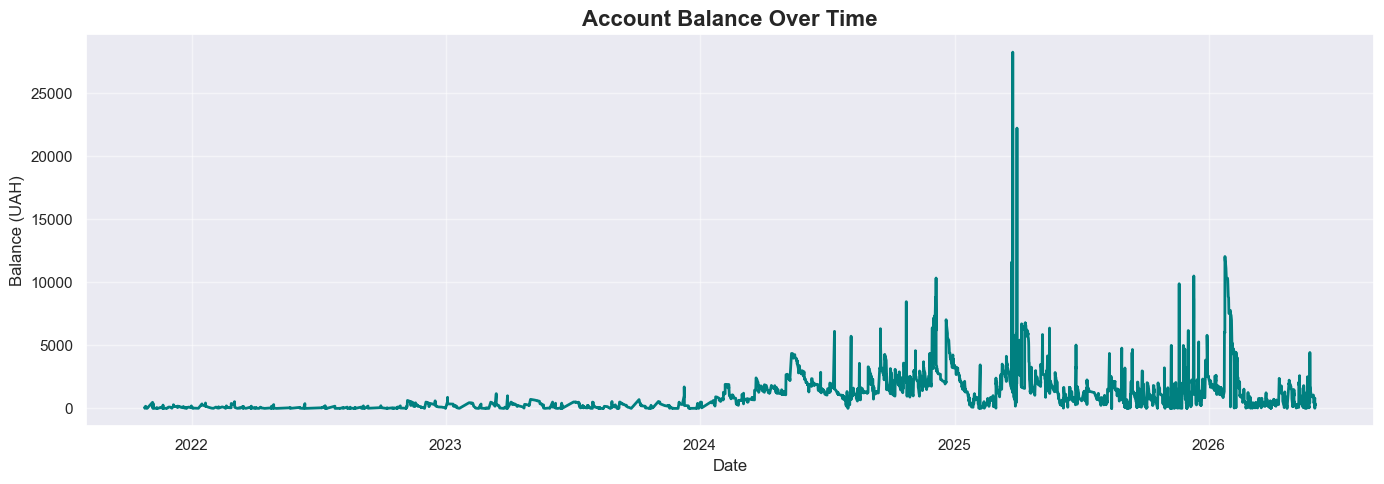

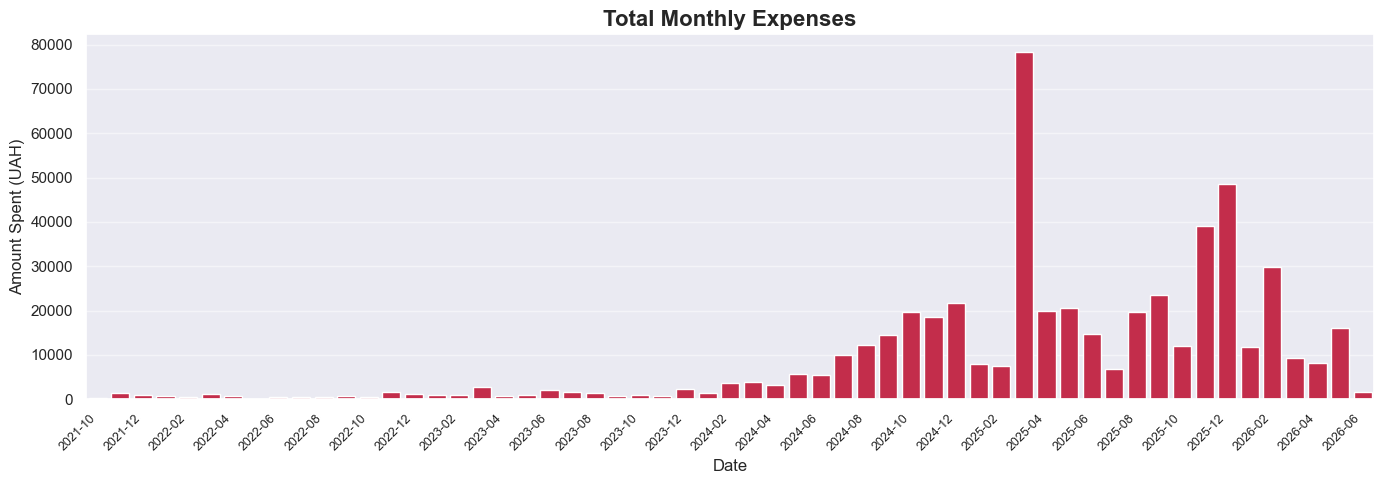

In [49]:
sns.set_theme(style="darkgrid", palette="deep")

plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='time', y='balance', color='teal', linewidth=2)
plt.title("Account Balance Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Balance (UAH)", fontsize=12)
plt.tight_layout()
plt.show()

expenses = df[df['amount'] < 0].copy()
expenses['expense_amount'] = expenses['amount'].abs()

expenses['month'] = expenses['time'].dt.strftime('%Y-%m')
monthly_expenses = expenses.groupby('month')['expense_amount'].sum().reset_index()

plt.figure(figsize=(14, 5))
ax = sns.barplot(data=monthly_expenses, x='month', y='expense_amount', color='crimson')
plt.title("Total Monthly Expenses", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Amount Spent (UAH)", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)

for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 2 == 0:
        label.set_visible(True)
    else:
        label.set_visible(False)

plt.tight_layout()
plt.show()

## 5. Category Analysis (MCC Mapping)
Analyzing the distribution of expenses across different spending categories.

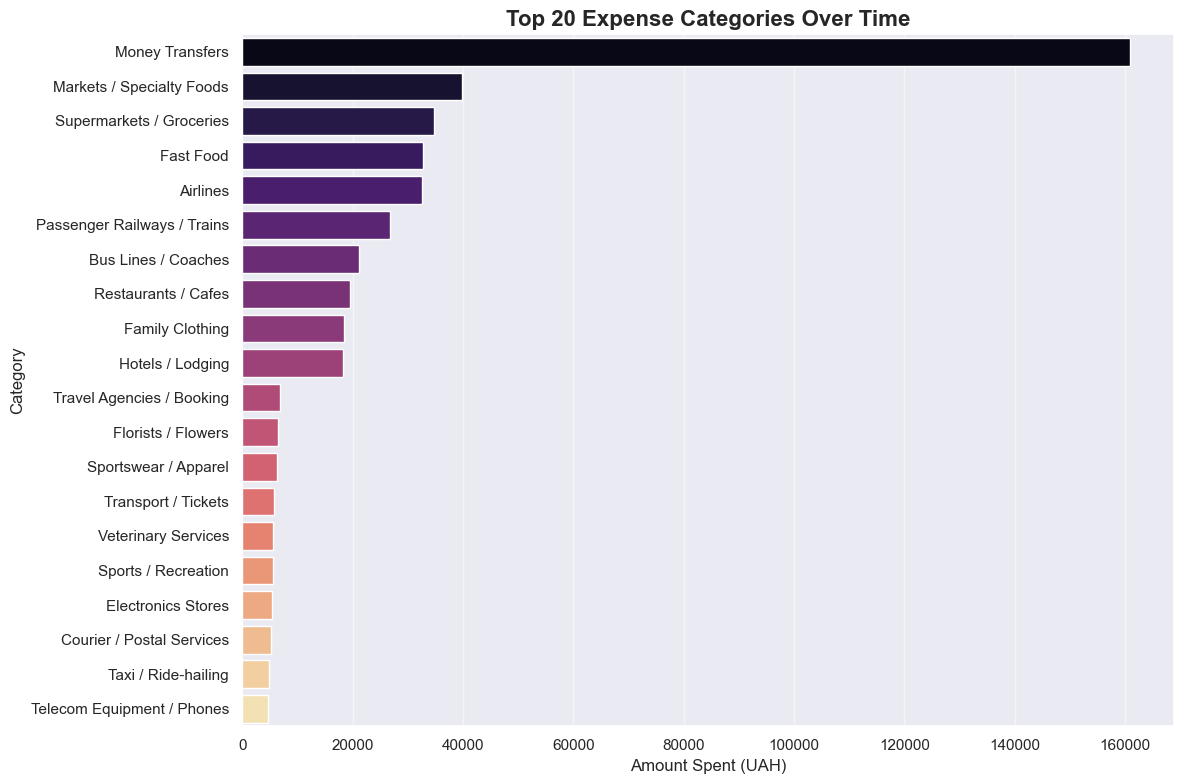


All categories:


,category,expense_amount
0,Money Transfers,160794.58
1,Markets / Specialty Foods,39913.49
2,Supermarkets / Groceries,34814.26
3,Fast Food,32724.58
4,Airlines,32548.18
...,...,...
75,Payment Services / Terminals,100.00
76,Sporting Goods / Fishing,70.00
77,Camera & Photo Supplies,50.00
78,Gift / Novelty Shops,50.00


In [50]:
category_totals = expenses.groupby('category')['expense_amount'].sum().sort_values(ascending=False).reset_index()

top_categories = category_totals.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_categories,
    x='expense_amount',
    y='category',
    hue='category',
    palette='magma',
    legend=False
)
plt.title("Top 20 Expense Categories Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Amount Spent (UAH)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.tight_layout()
plt.show()

print("\nAll categories:")
display(category_totals)

## 6. Temporal Analysis & Feature Engineering
Extracting day of the week from the transaction timestamps to identify weekly spending patterns and prepare features for future machine learning models.

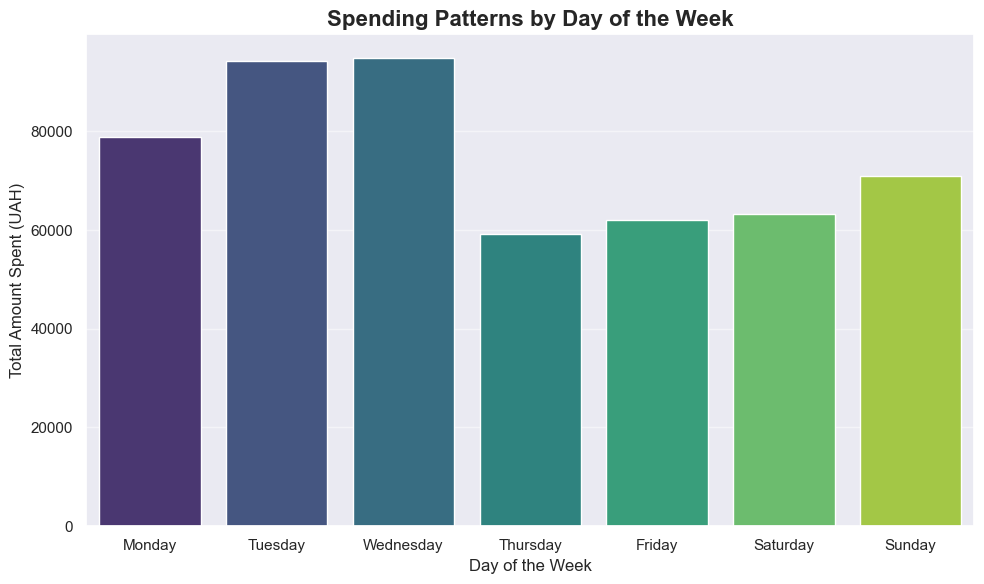

In [51]:
expenses['day_of_week'] = expenses['time'].dt.day_name()

cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
expenses['day_of_week'] = pd.Categorical(expenses['day_of_week'], categories=cats, ordered=True)

weekly_spending = expenses.groupby('day_of_week')['expense_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=weekly_spending,
    x='day_of_week',
    y='expense_amount',
    hue='day_of_week',
    palette='viridis',
    legend=False,
    dodge=False
)
plt.title("Spending Patterns by Day of the Week", fontsize=16, fontweight='bold')
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Total Amount Spent (UAH)", fontsize=12)
plt.tight_layout()
plt.show()